# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Deepak lal_

**Roll Number:** _023-24-0276_

**GitHub Repository:** _https://github.com/deepaklal-io/ML_Labs_

**Duration:** 3 Hours (independent, hands-on)



---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("D:/Telco-Customer-Churn.csv")   # update path/filename if different
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_A Telecommunication Company wants to understand that why and which customers are likely to leave and what the company is laking from like any service or anything else
and the target variable is "churn"_

**Answer 2:**
_5 columns that i expect to usefull predictors of churn are: [tenure, InternetService, PaymentMethod, MonthlyCharges, Contract]
and 2 columns that i expect to be useless as predictors are: [customerID, gender]_

**Answer 3:**
_1. why the customers are leaving one shop and go to another shop?
2. what should we improve to maintain quality and services?_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [4]:
# Task 4 — dataset shape, column names, data types
print("Shape: ",df.shape)
print(" ")
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
numerical_feature=df.select_dtypes(include="number").columns
print("Numeric Features ",numerical_feature)
print(" ")
categorical_features=df.select_dtypes(include="str").columns
print("Categerical Features: ", categorical_features)

Shape:  (7043, 21)
 
Numeric Features  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
 
Categerical Features:  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [5]:
# Task 5 — identify identifier columns / wrong data types
print(df[["customerID","gender"]])

      customerID  gender
0     7590-VHVEG  Female
1     5575-GNVDE    Male
2     3668-QPYBK    Male
3     7795-CFOCW    Male
4     9237-HQITU  Female
...          ...     ...
7038  6840-RESVB    Male
7039  2234-XADUH  Female
7040  4801-JZAZL  Female
7041  8361-LTMKD    Male
7042  3186-AJIEK    Male

[7043 rows x 2 columns]


In [6]:
# Task 6 — unique values in 3 categorical columns
print("Contract")
print(df["Contract"].unique())

print("\nInternet Services")
print(df["InternetService"].unique())

print("\nPayment Method")
print(df["PaymentMethod"].unique())

Contract
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Internet Services
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Payment Method
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Observations (Part 2):**
_I found above 4 are numerical columns and rest of the categorical. and TotalCharges is string columns while it contains numerical data_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [7]:
# Task 7 — missing values: count and percentage per column
missing_values=df.isnull().sum()
missing_per=df.isnull().mean()*100
missing_report=pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_per
})
print(missing_report)

                  Missing Values  Missing Percentage
customerID                     0            0.000000
gender                         0            0.000000
SeniorCitizen                  0            0.000000
Partner                        0            0.000000
Dependents                     0            0.000000
tenure                         0            0.000000
PhoneService                   0            0.000000
MultipleLines                  0            0.000000
InternetService                0            0.000000
OnlineSecurity                 0            0.000000
OnlineBackup                   0            0.000000
DeviceProtection               0            0.000000
TechSupport                    0            0.000000
StreamingTV                    0            0.000000
StreamingMovies                0            0.000000
Contract                       0            0.000000
PaperlessBilling               0            0.000000
PaymentMethod                  0            0.

In [8]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicated rows ", df.duplicated().sum())
print("Duplicated CustomerID ",df["customerID"].duplicated().sum())

Duplicated rows  0
Duplicated CustomerID  0


In [9]:
# Task 9 — investigate a suspicious / invalid value
print(df.info)

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

**Answer 7 (which missing-value problems need action, and why):**
_Total charges column contain 11 missing values out of 7043 instances. so we remove these waste from Data to maintain to clean Data_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_No.
They are related, but different:

Duplicate rows → the entire record is repeated.

Duplicate customer IDs → the same customer identifier appears multiple times, even if other information is different._

**Answer 9 (suspicious value found and how):**
_(your answer here)_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _ TotalCharges_ | _Remove rows with none values_ | _df.dropna()_ | _it directly removes the headache_ |
| _..._ | _..._ | _..._ | _..._ |
| _..._ | _..._ | _..._ | _..._ |

In [10]:
# Task 11 — apply your cleaning decisions here
df=df.dropna()

In [11]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

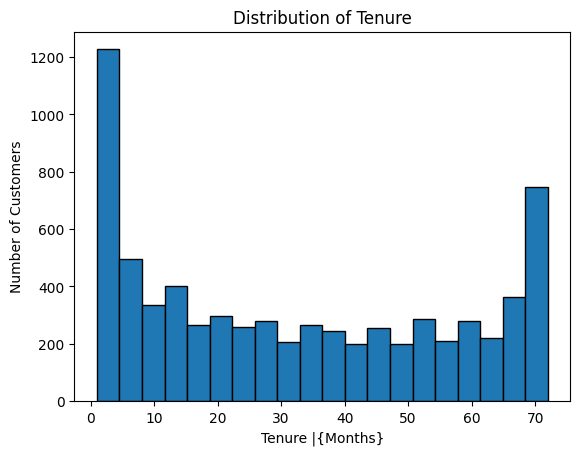

In [12]:
# Task 12 — numerical feature 1: distribution plot
import matplotlib.pyplot as plt
import seaborn as sns
df["tenure"].plot(kind="hist", edgecolor="black", bins=20)

plt.xlabel("Tenure |{Months}")
plt.ylabel("Number of Customers")
plt.title("Distribution of Tenure")

plt.show()

**Observation:** _Most customers in the company with different lengths of time. There are many customer with low tenue with company as well as customers stayed for several years._

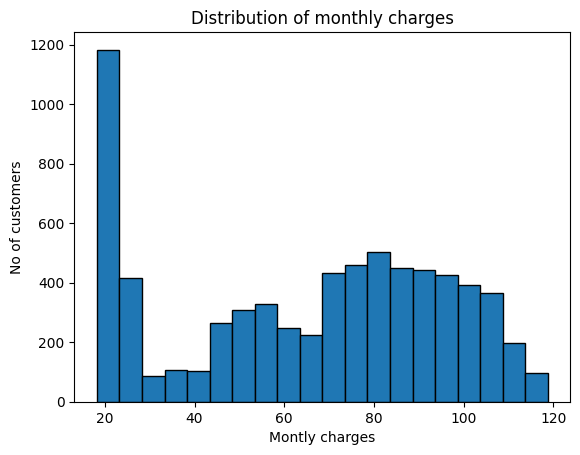

In [13]:
# Task 12 — numerical feature 2: distribution plot
df["MonthlyCharges"].plot(kind="hist", edgecolor="black", bins=20)
plt.xlabel("Montly charges")
plt.ylabel("No of customers")
plt.title("Distribution of monthly charges")
plt.show()

**Observation:** _Most customers have monthly charges in the middle range. There are fewer customers with very low or very high monthly charges._

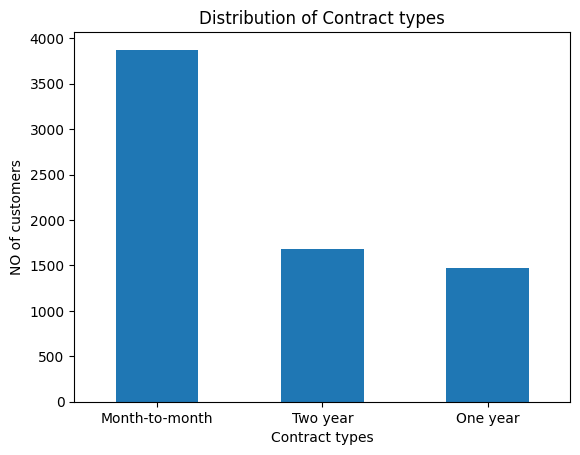

In [14]:
# Task 12 — categorical feature 1: distribution plot
df["Contract"].value_counts().plot(kind="bar")
plt.title("Distribution of Contract types")
plt.xlabel("Contract types")
plt.ylabel("NO of customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _Most customer have month to month contracts while fewer customers have two year and one year contract_

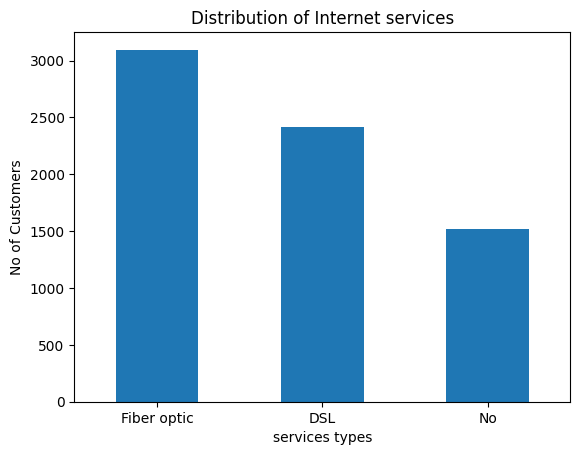

In [15]:
# Task 12 — categorical feature 2: distribution plot
df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("services types")
plt.ylabel("No of Customers")
plt.title("Distribution of Internet services")
plt.xticks(rotation=False)
plt.show()

**Observation:** _Most Customer uses Fiber Optics service while fewer uses DSL and fewer not uses these. This indicates that Internet Services play important part of the company's offering_

**Answer 13 (outliers / skew and possible explanation):**
_ Yes, some numerical features show skewed distributions. MonthlyCharges and especially TotalCharges can be right-skewed, meaning that most customers have lower or moderate charges while a smaller number of customers have much higher charges. This can be explained by differences in the services customers use and, for TotalCharges, by customers having different lengths of service. Tenure also has an uneven distribution because the dataset contains many customers with relatively short or medium tenure._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [16]:
# Task 14 — churn counts and percentages
churn_counts=df["Churn"].value_counts()
churn_per=df["Churn"].value_counts(normalize="True")*100

churn_report=pd.DataFrame({
    "Churn count": churn_counts,
    "Churn Percentage": churn_per
})

print(churn_report)

       Churn count  Churn Percentage
Churn                               
No            5163         73.421502
Yes           1869         26.578498


**Answer 14 (balanced or imbalanced?):**
_The target is imbalance because both values are not equal. around 73.42% are non churn while remaining 26.6% are churned. this means model well performed on majority class however it performs poorly on non churn class_

**Answer 15 (why imbalance might matter later):**
_Class imbalance matters because a classification model may become biased toward the majority class. In this dataset, a model could achieve high overall accuracy by predicting "No" for most customers while failing to correctly identify the customers who churn_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Text(0.5, 1.0, 'Churn rate by contract type')

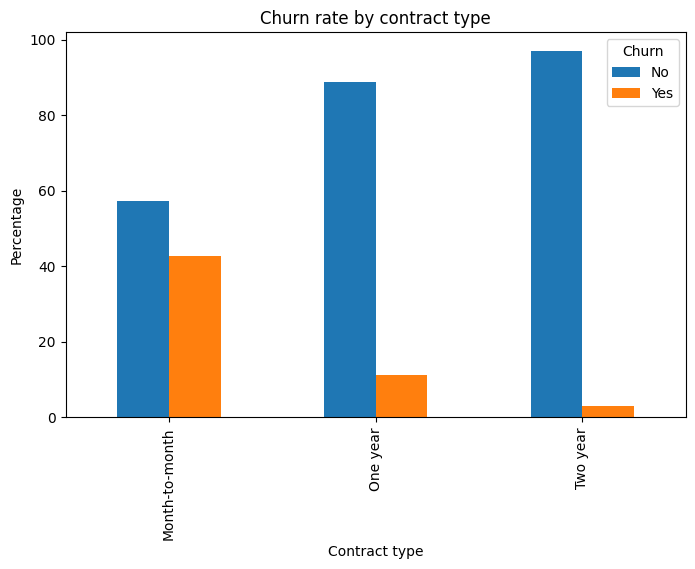

In [17]:
# Task 16 — categorical feature 1 vs Churn
cross_churn=pd.crosstab(df["Contract"],df["Churn"], normalize="index")*100
print(cross_churn)

cross_churn.plot(kind="bar", figsize=(8,5))
plt.xlabel("Contract type")
plt.ylabel("Percentage")
plt.title("Churn rate by contract type")

**Observation:** _customers with month to month contract have higher rate of churn while others are less compared to month to month_
**Evidence:** _The percentage of churn is yes is the highest for the month to month category. while two year contract have lower rate of churn._
**Possible Explanation:** _Customers with month to month contract have less commitments and they leave more easily while one year and two year category has high commitment than month to month._

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


Text(0.5, 1.0, 'Churn rate by Internet service type')

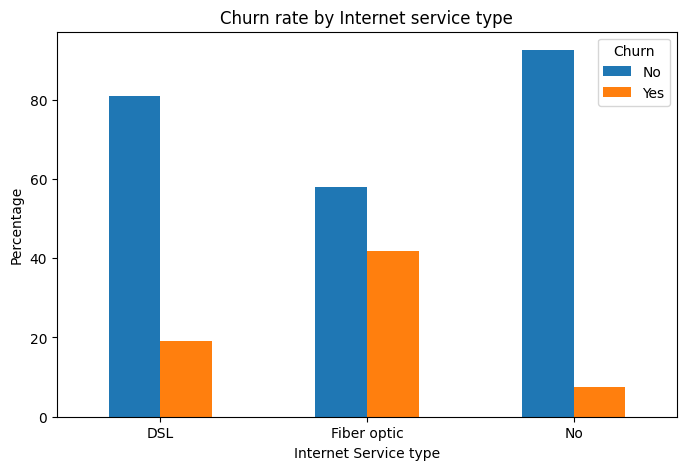

In [18]:
# Task 16 — categorical feature 2 vs Churn
cross_churnTwo=pd.crosstab(df["InternetService"],df["Churn"], normalize="index")*100
print(cross_churnTwo)

cross_churnTwo.plot(kind="bar", figsize=(8,5))
plt.xlabel("Internet Service type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.title("Churn rate by Internet service type")

**Observation:** _customer has high churn rate which they using fiber optic rather than DSL has low churn rate._
**Evidence:** _Fiber optics category has high churn = YES, compared with other internet services like DSL_
**Possible Explanation:** _FIber optic may have high monthly charges or may have more compitative alternatives. Service quality or charges could also influence their decision to leave_

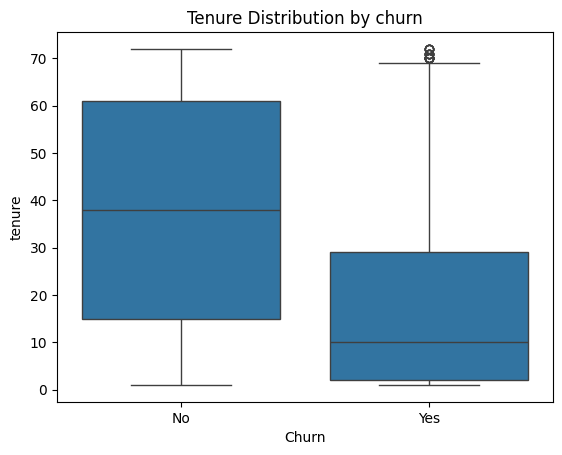

In [19]:
# Task 17 — numerical feature 1 vs Churn
sns.boxplot(x="Churn",y="tenure",data=df)
plt.xlabel=("Churn")
plt.ylabel=("Tenure (Months)")
plt.title("Tenure Distribution by churn")
plt.show()


**Observation:** _customer who churn generally have lower tenure than customers have churn_
**Evidence:** _above Boxplot visualize that churn boxplot graph has lower than no churn boxplot._
**Possible Explanation:** _less tenure customer are not strongly attached and may be more likely to switch to the compitators. while higher tenure customers may have developed loyality and satisfaction with the service._

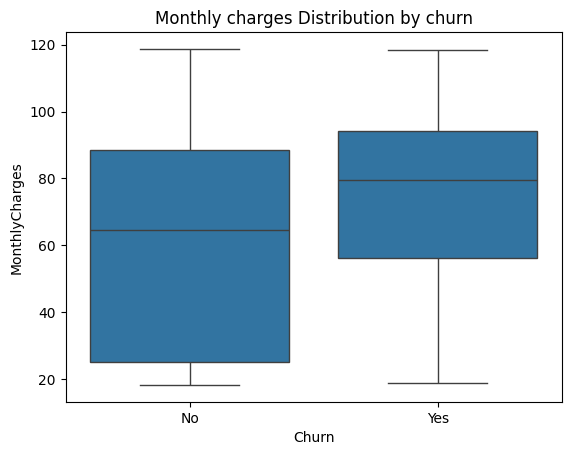

In [20]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.xlabel=("Churn")
plt.ylabel=("Monthly Charges")
plt.title("Monthly charges Distribution by churn")
plt.show()

**Observation:** _customers who churn generally have high monthly charges than who dont churn_
**Evidence:** _the median Monthly charges for churn=yes is higher than median for churn= NO_
**Possible Explanation:** _it can be say that other competitor are not taking monthly charges thats why customers leaving the company and switch to compititors._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015683        0.219874      0.102411
tenure               0.015683  1.000000        0.246862      0.825880
MonthlyCharges       0.219874  0.246862        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


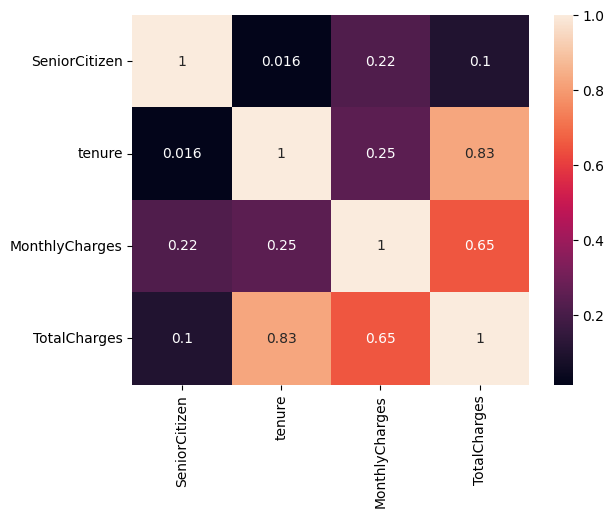

In [21]:
# Task 18 — correlation matrix and heatmap
correlation_numeric=df.corr(numeric_only=True)
print(correlation_numeric)
sns.heatmap(correlation_numeric,annot=True)
plt.show()

**Answer 18 (most correlated pairs):**
_Tenure and monthly charges appears to be most strongly positive correlated because customer who have stayed longer generally accumulate higher total charges. MonthlyCharges and TotalCharges also show a positive correlation. _

**Answer 19 (correlation vs. causation; potential problems):**
_No, correlation does not imply causation. Highly correlated features may contain similar or redundant information, which can cause multicollinearity problems in some future models, such as logistic regression._

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_CustomerID is a suspect because its a identifier and doesnt provide meaningfull information about customer Churn_

**Answer 21 (what would go wrong):**
_The model would cheat.

It could use the leaked information to make predictions that look extremely accurate during training/testing.

But when you use the model on real future customers, that information wouldn't be available, so the model would perform much worse._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Only identifies the customer; it does not provide useful predictive information. |
| tenure | Numerical | Feature | keep| Shows how long the customer has been with the company. |
| Contract | Categorical | Feature | keep | Contract type is an important factor that may influence churn. |
| Churn | Categorical | Target | Keep | This is the outcome the model is trying to predict. |
| ... | ... | ... | ... | ... |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [22]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

clean_df=clean_df.drop_duplicates()

clean_df = clean_df.drop(columns=["customerID"], errors="ignore")

clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

numeric_cols = clean_df.select_dtypes(include="number").columns

for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

categorical_cols = clean_df.select_dtypes(include="object").columns

for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

clean_df["Churn"] = clean_df["Churn"].astype("object")

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


C:\Users\BAJAJ COMPUTER\AppData\Local\Temp\ipykernel_6796\59512555.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = clean_df.select_dtypes(include="object").columns


In [24]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
# Check missing values
print("\nMissing values:")
print(clean_df.isna().sum())

# Check duplicates
print("\nNumber of duplicate rows:")
print(clean_df.duplicated().sum())


print("\nShape:")
print(clean_df.shape)


print("\nFirst 5 rows:")
print(clean_df.head())


Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of duplicate rows:
22

Shape:
(7032, 20)

First 5 rows:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity Online

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _A significant portion of customers have churned._
- Evidence: _The Churn column contains both Yes and No, with the majority of customers being non-churned._
- Interpretation: _Churn is an important business problem, and the dataset can be used to build a classification model to identify customers who are likely to leave._

**Finding 2**
- Observation: _Customers with shorter tenure appear more likely to churn._
- Evidence: _The tenure distribution and boxplot analysis showed that churned customers generally have lower tenure than customers who stayed._
- Interpretation: _Newer customers may be less loyal or less committed to the service, making early customer retention especially important._

**Finding 3**
- Observation: _Customers using month-to-month contracts have higher churn._
- Evidence: _The Contract vs. Churn analysis showed a noticeably higher proportion of churn among month-to-month customers compared with customers on one-year or two-year contracts._
- Interpretation: _Contract type appears to be strongly associated with customer churn. Customers without long-term commitments may find it easier to leave._

**Finding 4**
- Observation: _Customers using electronic check as their payment method show relatively high churn._
- Evidence: _The PaymentMethod vs. Churn analysis showed a higher churn proportion for electronic-check customers._
- Interpretation: _Payment method may be useful for identifying groups with increased churn risk, although it does not necessarily mean the payment method itself causes churn._

**Finding 5**
- Observation: _Some service-related and billing features are associated with different churn rates._
- Evidence: _The categorical comparisons and correlation analysis showed that features such as InternetService, OnlineSecurity, TechSupport, MonthlyCharges, and TotalCharges have relationships with customer behavior._
- Interpretation: _Churn is influenced by multiple factors rather than one single feature, so a machine-learning model should consider several relevant features together._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _The most important data-quality issue was the presence of missing/invalid values in TotalCharges. The column appeared numeric but contained values that needed to be converted to a numeric data type. These values had to be handled before machine learning._
2. What was the most interesting pattern you discovered?
   _The most interesting pattern was that customers with month-to-month contracts and shorter tenure were much more likely to churn. This suggests that customers who have not yet developed a long-term relationship with the company are at greater risk of leaving._
3. Which feature seems most useful for predicting churn?
   _Contract appears to be one of the most useful features because there is a clear difference in churn rates between month-to-month, one-year, and two-year contracts. tenure also appears highly useful because churn is more common among customers with shorter tenure._
4. Which feature should probably not be used, and why?
   _customerID should probably not be used because it is an identifier rather than a meaningful customer characteristic. It does not provide useful information about why a customer might churn and could cause the model to learn meaningless patterns._
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _Before modeling, categorical features will need to be encoded into numerical representations, and numerical features may need to be scaled depending on the algorithm. Missing values and duplicates should already be handled. The dataset will then need to be separated into features (X) and target (y), followed by a train/test split. Importantly, preprocessing steps such as scaling should be fitted using the training data to avoid data leakage._
6. What would you do next if you had another 3 hours?
   _I would first build a few baseline classification models, such as Logistic Regression, Decision Tree, and Random Forest. I would compare them using appropriate metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. I would then examine feature importance and investigate which customer characteristics contribute most to churn. Finally, I would tune the best-performing model and evaluate it on unseen test data._

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [✔ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [✔] A working `clean_df`, saved as `clean_churn.csv`
- [✔] A completed ML-readiness table (Part 10) covering every column
- [✔] Five Key Findings written (Part 12)
- [✔] Answered all six Final Reflection questions
- [✔] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [✔] Added your GitHub repository link at the top of this notebook